# 01 — Dataset Audit

This notebook documents and reproduces the **shared data foundation** for the Edge AI mosquito project.

It covers:

- **1.1 Metadata audit**
- **1.2 Core dataset selection**
- **1.3 Source-safe split validation**
- **1.4 WAV/audio audit**

The two model branches — **Reference Log-Mel** and **Edge MFE** — only start **after segmentation**, so this notebook must remain model-independent.

---

## Frozen Core definition

We use only:

- `sound_type == "mosquito"`
- `plurality == "Single"`
- native `sample_rate == 44100`
- four species:
  - `an arabiensis`
  - `an funestus ss`
  - `an squamosus`
  - `culex pipiens complex`

We group data by the original source recording column `name` to prevent source leakage.

In [1]:
# ============================================================
# CELL 1 — Imports and project paths
# ============================================================

from pathlib import Path
import wave

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\VGU-27\Edge AI Project")
DATA_DIR = PROJECT / "data"
AUDIO_DIR = DATA_DIR / "audio"

METADATA_PATH = DATA_DIR / "neurips_2021_zenodo_0_0_1.csv"
CORE_PATH = DATA_DIR / "core_single_4species_metadata.csv"
SPLIT_PATH = DATA_DIR / "core_single_4species_frozen_split.csv"

print("Project:", PROJECT)
print("Metadata exists:", METADATA_PATH.exists())
print("Core metadata exists:", CORE_PATH.exists())
print("Frozen split exists:", SPLIT_PATH.exists())
print("Audio directory exists:", AUDIO_DIR.exists())

Project: D:\VGU-27\Edge AI Project
Metadata exists: True
Core metadata exists: True
Frozen split exists: True
Audio directory exists: True


## 1.1 — Metadata audit

First, inspect the original HumBugDB metadata without changing anything.

The aim is to understand:

- number of rows,
- available columns,
- `sound_type`,
- sample rates,
- raw species labels,
- whether `id` is unique.

In [2]:
# ============================================================
# CELL 2 — Load original metadata
# ============================================================

metadata = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata.shape)
print("\nColumns:")
print(metadata.columns.tolist())

print("\nUnique IDs:", metadata["id"].nunique())
print("Duplicate IDs:", metadata["id"].duplicated().sum())

display(metadata.head())

Metadata shape: (9295, 19)

Columns:
['id', 'length', 'name', 'sample_rate', 'record_datetime', 'sound_type', 'species', 'gender', 'fed', 'plurality', 'age', 'method', 'mic_type', 'device_type', 'country', 'district', 'province', 'place', 'location_type']

Unique IDs: 9295
Duplicate IDs: 0


,id,length,name,sample_rate,record_datetime,sound_type,species,gender,fed,plurality,age,method,mic_type,device_type,country,district,province,place,location_type
0,199980,1121.880000,background.wav,8000,08-09-16 08:00,background,NaN,NaN,NaN,NaN,NaN,NaN,phone,Alcatel 4009X,USA,Georgia,Atlanta,"CDC insect cultures, Atlanta",culture
1,53,0.463456,CDC_Ae-aegypti_labelled_800.wav,8000,08-09-16 08:00,mosquito,ae aegypti,NaN,NaN,Single,NaN,NaN,phone,Alcatel 4009X,USA,Georgia,Atlanta,"CDC insect cultures, Atlanta",culture
2,57,0.170249,CDC_Ae-aegypti_labelled_800.wav,8000,08-09-16 08:00,mosquito,ae aegypti,NaN,NaN,Single,NaN,NaN,phone,Alcatel 4009X,USA,Georgia,Atlanta,"CDC insect cultures, Atlanta",culture
3,61,0.104041,CDC_Ae-aegypti_labelled_800.wav,8000,08-09-16 08:00,mosquito,ae aegypti,NaN,NaN,Single,NaN,NaN,phone,Alcatel 4009X,USA,Georgia,Atlanta,"CDC insect cultures, Atlanta",culture
4,69,0.274290,CDC_Ae-aegypti_labelled_800.wav,8000,08-09-16 08:00,mosquito,ae aegypti,NaN,NaN,Single,NaN,NaN,phone,Alcatel 4009X,USA,Georgia,Atlanta,"CDC insect cultures, Atlanta",culture


In [3]:
# ============================================================
# CELL 3 — Basic metadata distributions
# ============================================================

print("SOUND TYPE")
print(metadata["sound_type"].value_counts(dropna=False))

print("\nSAMPLE RATE")
print(metadata["sample_rate"].value_counts(dropna=False))

print("\nTOP SPECIES")
print(metadata["species"].value_counts(dropna=False).head(20))

SOUND TYPE
sound_type
mosquito      6795
background    1900
audio          600
Name: count, dtype: int64

SAMPLE RATE
sample_rate
44100    6102
8000     3193
Name: count, dtype: int64

TOP SPECIES
species
NaN                       3287
an arabiensis             1985
an gambiae ss              737
culex quinquefasciatus     678
culex pipiens complex      545
an funestus ss             381
an squamosus               141
ma uniformis               131
an dirus                   129
an harrisoni               124
ae aegypti                 123
an maculatus               117
an funestus sl             104
an coustani                 92
ae albopictus               79
an maculipalpis             79
ma africanus                78
an quadriannulatus          70
an albimanus                55
an freeborni                52
Name: count, dtype: int64


### Expected audit result

For HumBugDB release `0.0.1`, the working metadata used in this project should contain **9295 rows**.

Important observations from the previous audit:

- mosquito rows: `6795`
- background rows: `1900`
- audio rows: `600`
- sample rates include both `44100` and `8000`

Because sample rate is strongly associated with source groups/species in this dataset, the Core subset will use only native **44.1 kHz** recordings.

In [4]:
# Optional frozen-dataset assertion.
# If this fails, stop and investigate before continuing.

assert len(metadata) == 9295, (
    f"Unexpected metadata size: {len(metadata)} rows. "
    "Expected 9295 for the frozen HumBugDB release used in this project."
)

assert metadata["id"].is_unique, "Metadata ID column is not unique."

print("1.1 metadata audit: PASS")

1.1 metadata audit: PASS


## 1.2 — Recreate the Core subset

The Core experiment is **single-mosquito species classification**.

We deliberately exclude:

- `background`,
- generic `audio`,
- plurality `Plural`,
- plurality `NaN`,
- species outside the four Core classes,
- native 8 kHz recordings.

This avoids silently assuming that missing plurality means "Single", and reduces obvious sample-rate/domain confounding.

In [5]:
# ============================================================
# CELL 4 — Strict Core filter
# ============================================================

CORE_SPECIES = [
    "an arabiensis",
    "an funestus ss",
    "an squamosus",
    "culex pipiens complex",
]

recreated_core = metadata[
    (metadata["sound_type"] == "mosquito")
    & (metadata["plurality"] == "Single")
    & (metadata["species"].isin(CORE_SPECIES))
    & (metadata["sample_rate"] == 44100)
].copy()

print("Core clips:", len(recreated_core))
print("Unique IDs:", recreated_core["id"].nunique())
print("Unique source recordings:", recreated_core["name"].nunique())

print("\nClips per species:")
print(recreated_core["species"].value_counts())

print("\nSources per species:")
print(
    recreated_core.groupby("species")["name"]
    .nunique()
    .sort_values(ascending=False)
)

Core clips: 1898
Unique IDs: 1898
Unique source recordings: 1189

Clips per species:
species
an arabiensis            831
culex pipiens complex    545
an funestus ss           381
an squamosus             141
Name: count, dtype: int64

Sources per species:
species
an arabiensis            514
culex pipiens complex    336
an funestus ss           248
an squamosus              91
Name: name, dtype: int64


In [6]:
# ============================================================
# CELL 5 — Core summary table
# ============================================================

core_summary = (
    recreated_core
    .groupby("species")
    .agg(
        clips=("id", "count"),
        sources=("name", "nunique"),
        total_duration_s=("length", "sum"),
        median_duration_s=("length", "median"),
        min_duration_s=("length", "min"),
        max_duration_s=("length", "max"),
    )
    .sort_values("clips", ascending=False)
)

display(core_summary)

,clips,sources,total_duration_s,median_duration_s,min_duration_s,max_duration_s
species,,,,,,
an arabiensis,831,514,14815.20,12.74,2.5,117.76
culex pipiens complex,545,336,8157.76,10.24,2.5,53.70
an funestus ss,381,248,7414.24,15.30,2.5,81.86
an squamosus,141,91,2091.80,10.24,2.5,46.02


In [7]:
# ============================================================
# CELL 6 — Check against the previously saved Core file
# ============================================================

saved_core = pd.read_csv(CORE_PATH)

same_ids = set(saved_core["id"]) == set(recreated_core["id"])

print("Saved Core rows:", len(saved_core))
print("Recreated Core rows:", len(recreated_core))
print("Same exact ID set:", same_ids)

assert len(recreated_core) == 1898
assert recreated_core["id"].nunique() == 1898
assert recreated_core["name"].nunique() == 1189
assert same_ids

expected_clips = {
    "an arabiensis": 831,
    "culex pipiens complex": 545,
    "an funestus ss": 381,
    "an squamosus": 141,
}

actual_clips = recreated_core["species"].value_counts().to_dict()
assert actual_clips == expected_clips

print("1.2 Core selection: PASS")

Saved Core rows: 1898
Recreated Core rows: 1898
Same exact ID set: True
1.2 Core selection: PASS


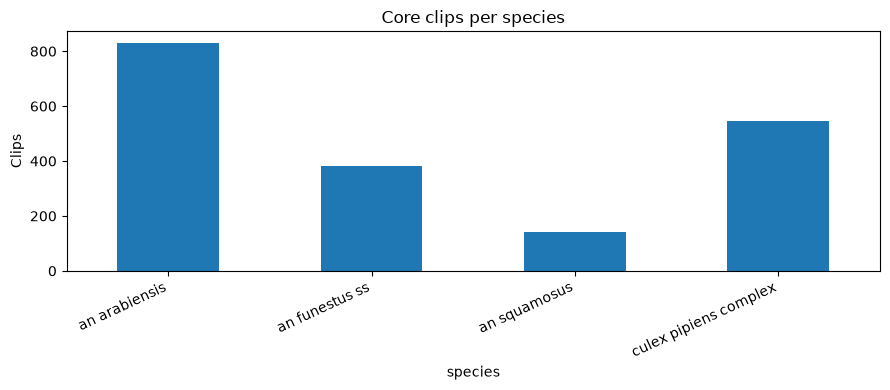

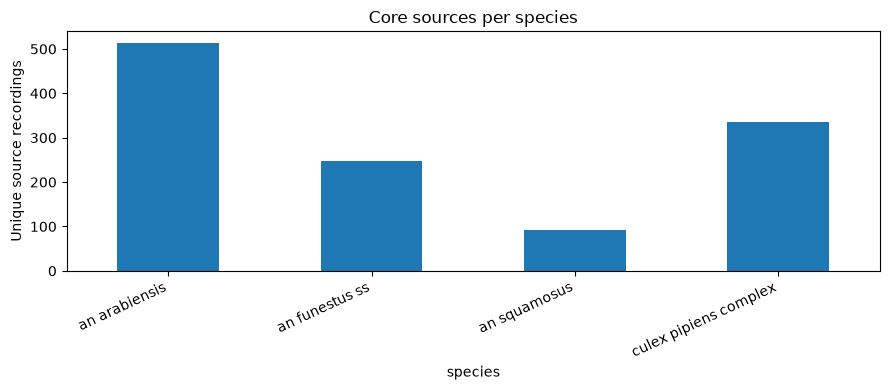

In [8]:
# ============================================================
# CELL 7 — Visualize clip and source counts
# ============================================================

clip_counts = recreated_core["species"].value_counts().sort_index()
source_counts = recreated_core.groupby("species")["name"].nunique().sort_index()

plt.figure(figsize=(9, 4))
clip_counts.plot(kind="bar")
plt.ylabel("Clips")
plt.title("Core clips per species")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
source_counts.plot(kind="bar")
plt.ylabel("Unique source recordings")
plt.title("Core sources per species")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 1.3 — Validate the frozen source-safe split

The split is performed by `name`, not by clip ID.

Why?

Multiple metadata rows can originate from the **same original source recording**. If clips from one source appear in both train and test, the model may learn recording-specific characteristics instead of species acoustics.

The split is already frozen. This notebook **must not regenerate it**.

In [9]:
# ============================================================
# CELL 8 — Load frozen split
# ============================================================

split_df = pd.read_csv(SPLIT_PATH)

print("Rows:", len(split_df))
print("Unique IDs:", split_df["id"].nunique())
print("Unique sources:", split_df["name"].nunique())

print("\nClip counts by split:")
print(split_df["split"].value_counts())

print("\nSpecies × split:")
display(pd.crosstab(split_df["species"], split_df["split"]))

Rows: 1898
Unique IDs: 1898
Unique sources: 1189

Clip counts by split:
split
train         1335
test           294
validation     269
Name: count, dtype: int64

Species × split:


split,test,train,validation
species,,,
an arabiensis,124,588,119
an funestus ss,61,267,53
an squamosus,23,99,19
culex pipiens complex,86,381,78


In [10]:
# ============================================================
# CELL 9 — Leakage checks
# ============================================================

source_split_counts = split_df.groupby("name")["split"].nunique()
leaked_sources = source_split_counts[source_split_counts > 1]

core_species_per_source = split_df.groupby("name")["species"].nunique()
multi_core_species_sources = core_species_per_source[
    core_species_per_source > 1
]

print("Sources appearing in >1 split:", len(leaked_sources))
print("Sources containing >1 Core species:", len(multi_core_species_sources))

if len(leaked_sources):
    display(leaked_sources.head())

if len(multi_core_species_sources):
    display(multi_core_species_sources.head())

Sources appearing in >1 split: 0
Sources containing >1 Core species: 0


In [11]:
# ============================================================
# CELL 10 — Frozen split assertions
# ============================================================

expected_split_counts = {
    "train": 1335,
    "test": 294,
    "validation": 269,
}

assert len(split_df) == 1898
assert split_df["id"].nunique() == 1898
assert split_df["name"].nunique() == 1189
assert split_df["split"].value_counts().to_dict() == expected_split_counts
assert len(leaked_sources) == 0
assert len(multi_core_species_sources) == 0

print("1.3 source-safe split: PASS")

1.3 source-safe split: PASS


## 1.4 — WAV/audio audit

The metadata says the Core recordings are 44.1 kHz, but we verify the **actual files**.

Required properties:

- every WAV exists,
- mono,
- 44.1 kHz,
- PCM24 (`3 bytes/sample`),
- WAV duration agrees with metadata duration.

In [12]:
# ============================================================
# CELL 11 — Audit every WAV header
# ============================================================

audio_records = []

for n, (_, row) in enumerate(split_df.iterrows(), start=1):
    wav_path = AUDIO_DIR / f"{int(row['id'])}.wav"

    if not wav_path.exists():
        audio_records.append({
            "id": int(row["id"]),
            "exists": False,
        })
        continue

    with wave.open(str(wav_path), "rb") as wf:
        channels = wf.getnchannels()
        sample_width_bytes = wf.getsampwidth()
        sample_rate = wf.getframerate()
        frames = wf.getnframes()
        duration_wav = frames / sample_rate

    audio_records.append({
        "id": int(row["id"]),
        "exists": True,
        "sample_rate_wav": sample_rate,
        "channels": channels,
        "sample_width_bytes": sample_width_bytes,
        "frames": frames,
        "duration_wav": duration_wav,
    })

    if n % 250 == 0 or n == len(split_df):
        print(f"Audited {n}/{len(split_df)}")

audio_audit = pd.DataFrame(audio_records)

display(audio_audit.head())

Audited 250/1898
Audited 500/1898
Audited 750/1898
Audited 1000/1898
Audited 1250/1898
Audited 1500/1898
Audited 1750/1898
Audited 1898/1898


,id,exists,sample_rate_wav,channels,sample_width_bytes,frames,duration_wav
0,221149,True,44100,1,3,112896,2.560000
1,221150,True,44100,1,3,112895,2.559977
2,221145,True,44100,1,3,1693440,38.400000
3,221146,True,44100,1,3,225792,5.120000
4,221144,True,44100,1,3,112895,2.559977


In [13]:
# ============================================================
# CELL 12 — Join metadata duration and calculate mismatch
# ============================================================

duration_meta = split_df[["id", "length"]].copy()

audio_audit = audio_audit.merge(
    duration_meta,
    on="id",
    how="left",
)

audio_audit["duration_diff_s"] = (
    audio_audit["duration_wav"] - audio_audit["length"]
).abs()

print("Missing files:", (~audio_audit["exists"]).sum())
print("Non-44.1k:", (audio_audit["sample_rate_wav"] != 44100).sum())
print("Non-mono:", (audio_audit["channels"] != 1).sum())
print("Non-PCM24:", (audio_audit["sample_width_bytes"] != 3).sum())
print(
    "Duration mismatch >10 ms:",
    (audio_audit["duration_diff_s"] > 0.010).sum()
)

print("\nDuration difference statistics (s):")
print(audio_audit["duration_diff_s"].describe())

Missing files: 0
Non-44.1k: 0
Non-mono: 0
Non-PCM24: 0
Duration mismatch >10 ms: 0

Duration difference statistics (s):
count    1898.000000
mean        0.000005
std         0.000009
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000023
Name: duration_diff_s, dtype: float64


In [14]:
# ============================================================
# CELL 13 — WAV assertions
# ============================================================

assert audio_audit["exists"].all()
assert (audio_audit["sample_rate_wav"] == 44100).all()
assert (audio_audit["channels"] == 1).all()
assert (audio_audit["sample_width_bytes"] == 3).all()
assert (audio_audit["duration_diff_s"] <= 0.010).all()

print("1.4 WAV/audio audit: PASS")

1.4 WAV/audio audit: PASS


## Final result

If all assertions above pass, the shared data foundation is frozen:

**Dataset**
- 1898 clips
- 1189 source recordings
- 4 species
- all native 44.1 kHz / mono / PCM24

**Split**
- Train: 1335 clips
- Validation: 269 clips
- Test: 294 clips
- source leakage: 0

---

### What comes next

The next notebook is:

**`02_segmentation.ipynb`**

That notebook decides how to convert the frozen clips into model windows.

Only **after segmentation is frozen** do we branch into:

- **Reference Log-Mel**
- **Edge MFE / TinyML**

In [15]:
# ============================================================
# CELL 14 — Final compact summary
# ============================================================

final_summary = pd.Series({
    "core_clips": len(split_df),
    "source_recordings": split_df["name"].nunique(),
    "train_clips": (split_df["split"] == "train").sum(),
    "validation_clips": (split_df["split"] == "validation").sum(),
    "test_clips": (split_df["split"] == "test").sum(),
    "source_leakage": len(leaked_sources),
    "missing_wav": (~audio_audit["exists"]).sum(),
    "non_44100_hz": (audio_audit["sample_rate_wav"] != 44100).sum(),
    "non_mono": (audio_audit["channels"] != 1).sum(),
    "non_pcm24": (audio_audit["sample_width_bytes"] != 3).sum(),
    "duration_mismatch_gt_10ms": (
        audio_audit["duration_diff_s"] > 0.010
    ).sum(),
})

display(final_summary.to_frame("value"))

print("\n01_DATASET_AUDIT: PASS")

,value
core_clips,1898
source_recordings,1189
train_clips,1335
validation_clips,269
test_clips,294
source_leakage,0
missing_wav,0
non_44100_hz,0
non_mono,0
non_pcm24,0



01_DATASET_AUDIT: PASS


In [16]:
from pathlib import Path
import subprocess
import sys

NOTEBOOK_PATH = PROJECT / "notebooks" / "current" / "01_dataset_audit.ipynb"
PDF_DIR = PROJECT / "reports" / "pdf"

PDF_DIR.mkdir(parents=True, exist_ok=True)

assert NOTEBOOK_PATH.exists(), f"Notebook not found: {NOTEBOOK_PATH}"

PDF_PATH = PDF_DIR / f"{NOTEBOOK_PATH.stem}.pdf"

print("Notebook :", NOTEBOOK_PATH)
print("PDF      :", PDF_PATH)
print("\nExporting with nbconvert + XeLaTeX...")

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "pdf",
        "--output",
        NOTEBOOK_PATH.stem,
        "--output-dir",
        str(PDF_DIR),
        str(NOTEBOOK_PATH),
    ],
    capture_output=True,
    text=True,
)

if result.returncode != 0:
    print("\n--- stdout ---")
    print(result.stdout)

    print("\n--- stderr ---")
    print(result.stderr)

    raise RuntimeError("PDF EXPORT: FAILED")

assert PDF_PATH.exists(), f"PDF was not created: {PDF_PATH}"

print("\n" + "=" * 70)
print("PDF EXPORT: PASS")
print("=" * 70)
print("Saved:", PDF_PATH)

Notebook : D:\VGU-27\Edge AI Project\notebooks\current\01_dataset_audit.ipynb
PDF      : D:\VGU-27\Edge AI Project\reports\pdf\01_dataset_audit.pdf

Exporting with nbconvert + XeLaTeX...

PDF EXPORT: PASS
Saved: D:\VGU-27\Edge AI Project\reports\pdf\01_dataset_audit.pdf
